# Bab 2.2 — Hasil Analisis: visualisasi & output

Menjalankan notebook ini menghasilkan **seluruh figur (PNG) dan tabel (CSV)** untuk Bab 2.2 di folder `outputs/figur_22/`, siap di-*insert* ke esai.

> Catatan metodologis: deteksi keluhan berbasis **kata kunci** (pada 2.2.1c dan 2.2.7) adalah *proxy* transparan untuk eksplorasi, **terpisah** dari analisis SERVQUAL berbasis model. Subbab 2.2.8 (Dashboard) memakai screenshot dari pengguna.

## Persiapan: pustaka, data, gaya grafik

In [1]:
# -*- coding: utf-8 -*-
"""Membuat seluruh figur & output untuk Bab 2.2 Hasil Analisis."""
import sys, json, re
from pathlib import Path
# codes/ harus di depan agar 'import absa' memakai modul LOKAL (codes/absa),
# bukan paket PyPI 'absa' yang kebetulan terpasang di site-packages.
sys.path.insert(0, r"C:\Users\Andalan\Documents\Lomba\Satria Data 2026 - Belmawa\codes")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

DATA = Path("C:\\Users\\Andalan\\Documents\\Lomba\\Satria Data 2026 - Belmawa\\data")
OUT = Path("C:\\Users\\Andalan\\Documents\\Lomba\\Satria Data 2026 - Belmawa\\codes\\outputs")
FIG = OUT / "figur_22"
FIG.mkdir(exist_ok=True)

# ---- gaya global ----
mpl.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.titlecolor": "#1d2530", "text.color": "#1d2530", "axes.labelcolor": "#36424f",
    "xtick.color": "#5d6b7a", "ytick.color": "#5d6b7a", "figure.dpi": 110,
})
OK, WARN, BAD = "#2f9e6f", "#c98a2b", "#d05a4e"
DIM_COLOR = {"Responsiveness": "#185FA5", "Reliability": "#0f766e",
             "Assurance": "#854F0B", "Empathy": "#A32D2D", "Tangibles": "#5b46c0"}
DIM_ORDER = ["Responsiveness", "Reliability", "Assurance", "Empathy", "Tangibles"]
DIM_LABEL = {"Responsiveness": "Antrean &\nwaktu tunggu", "Reliability": "Obat, rujukan\n& janji",
             "Assurance": "Kepercayaan\ntenaga medis", "Empathy": "Sikap &\nkeramahan",
             "Tangibles": "Kebersihan\n& fasilitas"}
WIL_COLOR = {"Bantul": "#0f766e", "Semarang": "#185FA5", "Surabaya": "#A33D2D"}


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / name, dpi=160, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print("  tersimpan:", name)

## Muat data & deteksi kata kunci



In [2]:
rv = pd.read_csv(DATA / "reviews_all.csv",
                 usecols=["review_id", "rating", "text_length", "wilayah",
                          "review_text", "puskesmas_id", "puskesmas_name"])
findings = pd.read_csv(OUT / "findings_full.csv")
topik = json.loads((OUT / "topik_kabupaten.json").read_text(encoding="utf-8"))
isu = pd.read_csv(OUT / "statistik" / "isu_kanonik_per_dimensi.csv")
profiles = json.loads((OUT / "puskesmas_profiles.json").read_text(encoding="utf-8"))
print(f"reviews_all={len(rv)} | findings={len(findings)} | puskesmas={len(profiles)}")

# Deteksi keluhan berbasis KATA KUNCI (proxy transparan untuk EDA & Sinyal)
KEYWORDS = ["lama", "antri", "antre", "nunggu", "lambat", "lelet", "kosong", "habis",
            "judes", "jutek", "kasar", "kecewa", "buruk", "jelek", "parah", "kapok",
            "ga ramah", "gak ramah", "tidak ramah", "dipersulit", "ribet", "bertele",
            "kotor", "jorok", "panas", "bau", "mahal", "dibentak", "cuek", "diabaikan",
            "ga jelas", "gak jelas", "tidak jelas", "salah", "nyusahin", "menyusahkan"]
_pat = re.compile("|".join(re.escape(k) for k in KEYWORDS), re.I)
rv["ada_keluhan_kk"] = rv["review_text"].fillna("").str.lower().apply(lambda t: bool(_pat.search(t)))

reviews_all=69031 | findings=17375 | puskesmas=127


## 2.2.1 Eksplorasi Data Awal

Lima visualisasi yang memberi gambaran awal data **sekaligus** memotivasi pilihan metode (mengapa membaca teks, mengapa fokus ulasan 1–2★).

In [3]:
print("\n== 2.2.1 EDA ==")

# --- (a) Distribusi rating (bentuk-U) ---
vc = rv["rating"].value_counts().sort_index()
pct = vc / vc.sum() * 100
ekstrem = pct.get(1, 0) + pct.get(5, 0)
fig, ax = plt.subplots(figsize=(6.4, 3.8))
bars = ax.bar(vc.index, vc.values,
              color=[BAD, BAD, "#cbd5e1", OK, OK], width=0.7)
for r, v in vc.items():
    ax.text(r, v + 800, f"{v/vc.sum()*100:.0f}%", ha="center", fontsize=10, color="#36424f")
ax.set_xlabel("Rating bintang"); ax.set_ylabel("Jumlah ulasan")
ax.set_title("Distribusi rating")
ax.set_xticks([1, 2, 3, 4, 5])
save(fig, "fig_2_2_1a_distribusi_rating.png")
print(f"  ekstrem (1 atau 5 bintang): {ekstrem:.1f}%")

# --- (b) Panjang teks per rating ---
med = rv.groupby("rating")["text_length"].median()
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.bar(med.index, med.values, color=["#A33D2D", "#c06a45", "#cbd5e1", "#8fb3a0", "#5fa07f"], width=0.7)
for r, v in med.items():
    ax.text(r, v + 3, f"{int(v)}", ha="center", fontsize=10, color="#36424f")
ax.set_xlabel("Rating bintang"); ax.set_ylabel("Median panjang teks (huruf)")
ax.set_title("Panjang teks ulasan per rating")
ax.set_xticks([1, 2, 3, 4, 5])
save(fig, "fig_2_2_1b_panjang_teks.png")
print(f"  median panjang: {med.round().to_dict()}")

# --- (c) Kritik tersembunyi: % ulasan ber-kata-keluhan per rating ---
kk = rv.groupby("rating")["ada_keluhan_kk"].mean() * 100
fig, ax = plt.subplots(figsize=(6.4, 3.8))
cols = [BAD, BAD, "#cbd5e1", WARN, WARN]
ax.bar(kk.index, kk.values, color=cols, width=0.7)
for r, v in kk.items():
    ax.text(r, v + 1.5, f"{v:.0f}%", ha="center", fontsize=10, color="#36424f")
ax.set_xlabel("Rating bintang"); ax.set_ylabel("% ulasan mengandung kata keluhan")
ax.set_title("Bintang tinggi pun bisa menyimpan keluhan")
ax.set_xticks([1, 2, 3, 4, 5])
ax.text(0.5, 0.9, f"Pada bintang 4–5, sekitar {(kk.get(4,0)+kk.get(5,0))/2:.0f}% ulasan tetap menyebut keluhan",
        transform=ax.transAxes, ha="center", fontsize=9.5, color="#5d6b7a", style="italic")
save(fig, "fig_2_2_1c_kritik_tersembunyi.png")
print(f"  %kata-keluhan per rating: {kk.round(1).to_dict()}")

# --- (d) Sebaran volume ulasan per puskesmas ---
vol = rv.groupby("puskesmas_id").size()
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.hist(vol.values, bins=30, color="#397DC1", alpha=0.85, edgecolor="white")
ax.set_xlabel("Jumlah ulasan per puskesmas"); ax.set_ylabel("Banyak puskesmas")
ax.set_title("Sebaran volume ulasan per puskesmas")
ax.axvline(vol.median(), color=BAD, ls="--", lw=1.5)
ax.text(vol.median() + vol.max() * 0.02, ax.get_ylim()[1] * 0.85,
        f"median = {int(vol.median())}", color=BAD, fontsize=9.5)
save(fig, "fig_2_2_1d_volume_per_puskesmas.png")
print(f"  volume per puskesmas: median={int(vol.median())} min={int(vol.min())} max={int(vol.max())}")

# --- (e) Rating antar-wilayah (% bintang 1) ---
share1 = rv.assign(satu=rv["rating"].eq(1)).groupby("wilayah")["satu"].mean() * 100
share1 = share1.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.bar(share1.index, share1.values, color=[WIL_COLOR[w] for w in share1.index], width=0.6)
for w, v in share1.items():
    ax.text(w, v + 0.4, f"{v:.0f}%", ha="center", fontsize=10, color="#36424f")
ax.set_ylabel("% ulasan bintang 1"); ax.set_title("Proporsi rating bintang 1 per wilayah")
save(fig, "fig_2_2_1e_rating_antarwilayah.png")
print(f"  %bintang-1 per wilayah: {share1.round(1).to_dict()}")


== 2.2.1 EDA ==


  tersimpan: fig_2_2_1a_distribusi_rating.png
  ekstrem (1 atau 5 bintang): 92.2%


  tersimpan: fig_2_2_1b_panjang_teks.png
  median panjang: {1: 146.0, 2: 149.0, 3: 86.0, 4: 43.0, 5: 30.0}
  tersimpan: fig_2_2_1c_kritik_tersembunyi.png
  %kata-keluhan per rating: {1: 62.8, 2: 57.9, 3: 40.5, 4: 21.7, 5: 7.2}


  tersimpan: fig_2_2_1d_volume_per_puskesmas.png
  volume per puskesmas: median=465 min=24 max=1955
  tersimpan: fig_2_2_1e_rating_antarwilayah.png
  %bintang-1 per wilayah: {'Surabaya': 17.3, 'Bantul': 13.0, 'Semarang': 6.3}


## 2.2.2 Keandalan Label

Bukti bahwa pelabelan model dapat dipercaya: kesepakatan antar-anotator (Cohen's κ), akurasi polaritas, dan F1 model terhadap *gold standard*.

In [4]:
print("\n== 2.2.2 Keandalan Label ==")
from absa.goldset import load_annotations
from absa import evaluate as ev
from absa.prompts import CATEGORIES

sample = pd.read_csv(OUT / "goldset_sample.csv", encoding="utf-8-sig", dtype={"review_id": str})
review_ids = sample["review_id"].tolist()
ann1 = ev.annotations_to_dict(load_annotations(OUT / "goldset_anotasi_1.xlsx"))
ann2 = ev.annotations_to_dict(load_annotations(OUT / "goldset_anotasi_2.xlsx"))
ann3 = ev.annotations_to_dict(load_annotations(OUT / "goldset_anotasi_3.xlsx"))

INQUIRY_IDS = {"PKM_BTL_025_R0969_f4e6222e", "PKM_SBY_037_R0160_24add134",
               "PKM_SBY_059_R1098_eb04597d", "PKM_BTL_025_R0960_93750f3b",
               "PKM_SBY_025_R0284_46ed14e4"}
gold = {}
for rid in review_ids:
    if rid in INQUIRY_IDS:
        continue
    for cat in CATEGORIES:
        a = ann1.get(rid, {}).get(cat, "")
        b = ann2.get(rid, {}).get(cat, "")
        c = ann3.get(rid, {}).get(cat, "")
        if a == b and a:
            gold.setdefault(rid, {})[cat] = a
        elif a == c and a:
            gold.setdefault(rid, {})[cat] = a
        elif b == c and b:
            gold.setdefault(rid, {})[cat] = b

raw = [json.loads(l) for l in open(OUT / "goldset_model_v2_raw.jsonl", encoding="utf-8")]
pred = ev.model_to_dict(raw)

kap = ev.kappa_detection(ann1, ann2, ann3, review_ids)
kap_pol = ev.kappa_polarity(ann1, ann2, ann3, review_ids)
acc, n_acc = ev.polarity_accuracy(gold, pred, review_ids)
skor = ev.score_detection(gold, pred, review_ids)
kpol_mean = float(kap_pol[kap_pol["pasangan"] == "(rata2)"]["kappa"].iloc[0])
print(f"  akurasi polaritas: {acc:.3f} (n={n_acc}) | kappa polaritas rata2: {kpol_mean}")

kdim = kap[kap["category"].isin(DIM_ORDER)].set_index("category").reindex(DIM_ORDER)
overall = float(kap[kap["category"] == "(KESELURUHAN)"]["κ_rata2"].iloc[0])
fig, ax = plt.subplots(figsize=(7, 3.8))
vals = kdim["κ_rata2"].astype(float).values
ax.bar(range(len(DIM_ORDER)), vals, color="#185FA5", width=0.62)
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10, color="#36424f")
ax.axhline(0.61, color=OK, ls="--", lw=1.2)
ax.text(len(DIM_ORDER) - 0.45, 0.63, "substansial (0,61)", color=OK, fontsize=8.5)
ax.set_xticks(range(len(DIM_ORDER)))
ax.set_xticklabels([d.replace(" ", "\n") for d in DIM_ORDER], fontsize=9)
ax.set_ylim(0, 1); ax.set_ylabel("Cohen's κ (rata-rata 3 pasang)")
ax.set_title(f"Kesepakatan antar-anotator per dimensi  ·  keseluruhan κ = {overall:.2f}")
save(fig, "fig_2_2_2a_kappa_dimensi.png")
print(f"  kappa deteksi overall {overall:.2f}")

sd = skor[skor["category"].isin(CATEGORIES)].set_index("category").reindex(CATEGORIES)
f1 = pd.to_numeric(sd["F1"], errors="coerce").fillna(0).values
macro = float(skor[skor["category"] == "(MACRO)"]["F1"].iloc[0])
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(range(len(CATEGORIES)), f1, color="#0f766e", width=0.62)
for i, v in enumerate(f1):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10, color="#36424f")
ax.set_xticks(range(len(CATEGORIES)))
ax.set_xticklabels([c.replace(" ", "\n") for c in CATEGORIES], fontsize=9)
ax.set_ylim(0, 1); ax.set_ylabel("F1")
ax.set_title(f"Kinerja model vs gold standard  ·  Macro-F1 = {macro:.2f}")
save(fig, "fig_2_2_2b_f1_kategori.png")
print(f"  Macro-F1={macro:.3f}")


== 2.2.2 Keandalan Label ==


  akurasi polaritas: 0.965 (n=229) | kappa polaritas rata2: 0.689
  tersimpan: fig_2_2_2a_kappa_dimensi.png
  kappa deteksi overall 0.74


  tersimpan: fig_2_2_2b_f1_kategori.png
  Macro-F1=0.752


## 2.2.3 Komposisi & Sebaran Keluhan (Gabungan 3 Wilayah)

Gambaran besar **seluruh 127 puskesmas dari ketiga wilayah digabung** (Bantul, Kota Semarang, Kota Surabaya) — bukan satu wilayah, bukan rata-rata wilayah: dimensi apa yang paling banyak dikeluhkan, dan isu spesifik yang paling sering muncul. Versi terpisah per wilayah disajikan pada figur berikutnya.

In [5]:
DIM_ORDER, DIM_COLOR

(['Responsiveness', 'Reliability', 'Assurance', 'Empathy', 'Tangibles'],
 {'Responsiveness': '#185FA5',
  'Reliability': '#0f766e',
  'Assurance': '#854F0B',
  'Empathy': '#A32D2D',
  'Tangibles': '#5b46c0'})


== 2.2.3 Komposisi & Sebaran ==


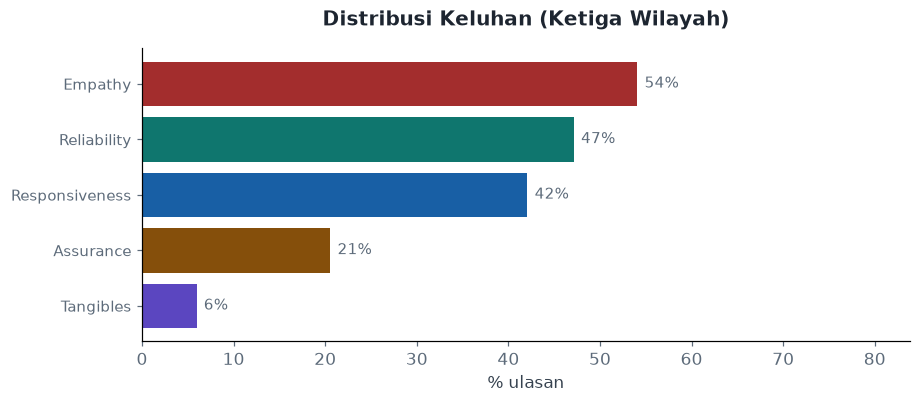

  tersimpan: fig_2_2_3a_komposisi_dimensi.png
  gabungan: [('Responsiveness', 42.1), ('Reliability', 47.1), ('Assurance', 20.6), ('Empathy', 54.1), ('Tangibles', 6.0)]


  tersimpan: fig_2_2_3a2_komposisi_per_wilayah.png
  Bantul: [('Responsiveness', 49), ('Reliability', 45), ('Assurance', 18), ('Empathy', 54), ('Tangibles', 7)]
  Semarang: [('Responsiveness', 25), ('Reliability', 42), ('Assurance', 15), ('Empathy', 37), ('Tangibles', 6)]
  Surabaya: [('Responsiveness', 45), ('Reliability', 49), ('Assurance', 23), ('Empathy', 59), ('Tangibles', 6)]


  tersimpan: fig_2_2_3b_isu_umum.png


In [6]:
print("\n== 2.2.3 Komposisi & Sebaran ==")
WILAYAH = ["Bantul", "Semarang", "Surabaya"]

# Komposisi dihitung dari SELURUH 127 puskesmas (gabungan 3 wilayah).
neg = findings[(findings["polarity"] == "neg") & (findings["dimension"].isin(DIM_ORDER))]


def komposisi(sub):
    t = sub["review_id"].nunique()
    return {d: (sub[sub["dimension"] == d]["review_id"].nunique() / t * 100 if t else 0) for d in DIM_ORDER}


comp_all = komposisi(neg)
npk_all = {d: neg[neg["dimension"] == d]["puskesmas_id"].nunique() for d in DIM_ORDER}
order = sorted(DIM_ORDER, key=lambda d: comp_all[d])          # kecil -> besar (untuk barh)

# --- (a) GABUNGAN: seluruh 127 puskesmas dari 3 wilayah ---
fig, ax = plt.subplots(figsize=(8.5, 3.8))
vals = [comp_all[d] for d in order]
ax.barh(range(len(order)), vals, color=[DIM_COLOR[d] for d in order])

ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=10)
for i, d in enumerate(order):
    ax.text(comp_all[d] + 0.8, i, f"{comp_all[d]:.0f}%",
            va="center", fontsize=9.5, color="#5d6b7a")
ax.set_xlabel("% ulasan")
ax.set_title("Distribusi Keluhan (Ketiga Wilayah)", pad=15)
ax.set_xlim(0, max(vals) * 1.55)

fig.tight_layout()
plt.show()
save(fig, "fig_2_2_3a_komposisi_dimensi.png")
print(f"  gabungan: {[(d, round(comp_all[d], 1)) for d in DIM_ORDER]}")

# --- (a2) PER WILAYAH: 3 subplot (urutan dimensi & skala-x sama untuk perbandingan) ---
xmax = max(komposisi(neg[neg["wilayah"] == w])[d] for w in WILAYAH for d in DIM_ORDER) * 1.18
fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.9), sharex=True)
for k, w in enumerate(WILAYAH):
    sub = neg[neg["wilayah"] == w]
    comp_w = komposisi(sub)
    ax = axes[k]
    ax.barh(range(len(order)), [comp_w[d] for d in order], color=[DIM_COLOR[d] for d in order])
    for i, d in enumerate(order):
        ax.text(comp_w[d] + xmax * 0.015, i, f"{comp_w[d]:.0f}%", va="center", fontsize=9, color="#5d6b7a")
    ax.set_xlim(0, xmax)
    n_ulasan = f"{sub['review_id'].nunique():,}".replace(",", ".")
    ax.set_title(f"{w}\n{sub['puskesmas_id'].nunique()} puskesmas, {n_ulasan} ulasan", fontsize=11)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order if k == 0 else [], fontsize=9.5)
    ax.set_xlabel("% ulasan")
fig.suptitle("Komposisi Keluhan per Wilayah", fontsize=13, fontweight="bold", y=1.05)
save(fig, "fig_2_2_3a2_komposisi_per_wilayah.png")
for w in WILAYAH:
    cw = komposisi(neg[neg["wilayah"] == w])
    print(f"  {w}: {[(d, round(cw[d])) for d in DIM_ORDER]}")

# --- (b) Isu spesifik paling umum (gabungan 3 wilayah) ---
top_isu = isu.sort_values("n_ulasan", ascending=False).head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.barh(range(len(top_isu)), top_isu["n_ulasan"].values,
        color=[DIM_COLOR.get(d, "#888") for d in top_isu["dimensi"]])
ax.set_yticks(range(len(top_isu))); ax.set_yticklabels(top_isu["isu_kanonik"], fontsize=9.5)
for i, v in enumerate(top_isu["n_ulasan"].values):
    ax.text(v + 8, i, f"{int(v)}", va="center", fontsize=9, color="#5d6b7a")
ax.set_xlabel("Jumlah ulasan"); ax.set_title("10 Keluhan Paling Umum (Ketiga Wilayah)")
ax.set_xlim(0, top_isu["n_ulasan"].max() * 1.13)
save(fig, "fig_2_2_3b_isu_umum.png")

## 2.2.4 Profil Keluhan per Puskesmas (contoh)

Contoh profil satu puskesmas (tabel pendukung). Tampilan utama subbab ini adalah **screenshot dashboard** tab Profil Puskesmas.

In [7]:
print("\n== 2.2.4 Profil contoh ==")
ex = profiles.get("PKM_SMG_007") or list(profiles.values())[0]
rows = []
for d in DIM_ORDER:
    dd = ex["dimensi"].get(d)
    if not dd:
        continue
    top = dd["top_sub_issues"][0]["isu"] if dd.get("top_sub_issues") else "-"
    rows.append({"Dimensi": d, "Tingkat keluhan (%)": round(dd["intensitas_rate"] * 100),
                 "CI 95%": dd["intensitas_ci95"], "Kepercayaan": dd["kepercayaan"],
                 "Isu utama": top})
prof_tbl = pd.DataFrame(rows)
prof_tbl.to_csv(FIG / "tabel_2_2_4_profil_contoh.csv", index=False, encoding="utf-8-sig")
print(f"  contoh: {ex['nama']} ({ex['wilayah']})")
print(prof_tbl.to_string(index=False))


== 2.2.4 Profil contoh ==
  contoh: Genuk (Semarang)
       Dimensi  Tingkat keluhan (%)       CI 95%    Kepercayaan                   Isu utama
Responsiveness                   14 [0.06, 0.31] Datanya sedang              pelayanan lama
   Reliability                   36 [0.21, 0.54] Datanya sedang informasi biaya tidak jelas
     Assurance                   14 [0.06, 0.31] Datanya sedang     kondisi pasien memburuk
       Empathy                   46 [0.30, 0.64] Datanya sedang          dokter tidak ramah
     Tangibles                   14 [0.06, 0.31] Datanya sedang       ventilasi udara buruk


## 2.2.5 Pola Antarwilayah

Uji χ² menunjukkan pola keluhan berbeda nyata antar wilayah; *heatmap* residual menunjuk sel (wilayah × dimensi) yang paling menyimpang.

In [8]:
import seaborn as sns

print("\n== 2.2.5 Pola Antarwilayah ==")
chi = topik["chi2_antar_wilayah"]
resid = pd.DataFrame(topik["residual_terstandarisasi"]).reindex(DIM_ORDER)
wils = list(resid.columns)
M = resid.values.astype(float)
fig, ax = plt.subplots(figsize=(6.2, 4.4))
vmax = float(np.nanmax(np.abs(M)))
im = ax.imshow(M, cmap="coolwarm", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(wils))); ax.set_xticklabels(wils)
ax.set_yticks(range(len(DIM_ORDER))); ax.set_yticklabels(DIM_ORDER)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i, j]:+.1f}", ha="center", va="center", fontsize=10,
                color="white" if abs(M[i, j]) > vmax * 0.55 else "#1d2530")
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("Residual terstandarisasi", fontsize=9)
p_str = "p < 0.001" if chi["p"] < 0.001 else f"p = {chi['p']:.3f}"

ax.set_title("Pola Keluhan Antarwilayah",
             fontsize=13, fontweight="bold", pad=18)

ax.text(
    0.5, 1.01,
    f"χ² = {chi['chi2']:.1f}, df = {chi['dof']}, {p_str}",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    color="#555555"
)
save(fig, "fig_2_2_5_residual_antarwilayah.png")
print(f"  chi2={chi['chi2']} df={chi['dof']} p={chi['p']:.2e}")


== 2.2.5 Pola Antarwilayah ==


  tersimpan: fig_2_2_5_residual_antarwilayah.png
  chi2=101.258 df=8 p=2.36e-18


## 2.2.6 Keterkaitan Keluhan

Pasangan dimensi yang cenderung muncul bersamaan dalam satu ulasan (lift > 1) — kandidat untuk dibenahi sekaligus.

In [9]:
print("\n== 2.2.6 Keterkaitan (lift) ==")
lift = pd.DataFrame(topik["co_occurrence_lift"]).dropna(subset=["lift"]).sort_values("lift")
fig, ax = plt.subplots(figsize=(7.2, 4.2))
labels = [f"{a} + {b}" for a, b in zip(lift["dim_a"], lift["dim_b"])]
cols = [OK if v > 1 else "#cbd5e1" for v in lift["lift"]]
ax.barh(range(len(lift)), lift["lift"].values, color=cols)
ax.axvline(1.0, color="#5d6b7a", ls="--", lw=1.2)
ax.set_yticks(range(len(lift))); ax.set_yticklabels(labels, fontsize=9)
for i, v in enumerate(lift["lift"].values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9, color="#5d6b7a")
ax.set_xlabel("Lift  (>1 = lebih sering bersamaan daripada kebetulan)")
ax.set_title("Keterkaitan Keluhan")
save(fig, "fig_2_2_6_lift.png")
print(f"  lift teratas: {labels[-1]} = {lift['lift'].iloc[-1]}")


== 2.2.6 Keterkaitan (lift) ==


  tersimpan: fig_2_2_6_lift.png
  lift teratas: Assurance + Empathy = 1.1


### 2.2.6b Breakdown lift per wilayah

Apakah pola "keluhan datang bersamaan" sama di tiap wilayah? Heatmap berikut memecah nilai *lift* tiap pasangan dimensi per wilayah.

In [10]:
print("\n== 2.2.6b Lift per wilayah ==")
from absa.stats import cooccurrence_lift
WIL = ["Bantul", "Semarang", "Surabaya"]
lifts = {w: cooccurrence_lift(findings[findings["wilayah"] == w]) for w in WIL}
base = lifts["Bantul"][["dim_a", "dim_b"]].copy()
base["pair"] = base["dim_a"] + " + " + base["dim_b"]
M = np.full((len(base), len(WIL)), np.nan)
for j, w in enumerate(WIL):
    lw = lifts[w].set_index(["dim_a", "dim_b"])["lift"]
    for i, r in base.iterrows():
        M[i, j] = lw.get((r["dim_a"], r["dim_b"]), np.nan)
oi = np.argsort(np.nanmean(M, axis=1)); M = M[oi]; pairs = base["pair"].values[oi]
fig, ax = plt.subplots(figsize=(6.6, 5))
im = ax.imshow(M, cmap="RdYlGn", vmin=0.6, vmax=1.4, aspect="auto")
ax.set_xticks(range(len(WIL))); ax.set_xticklabels(WIL)
ax.set_yticks(range(len(pairs))); ax.set_yticklabels(pairs, fontsize=9)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=9.5, color="#1d2530")
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.set_label("Lift", fontsize=9)
ax.set_title("Keterkaitan Keluhan per Wilayah", fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, "hijau = sering bersamaan, merah = jarang", 
        transform=ax.transAxes, ha='center', fontsize=10, color='gray')
save(fig, "fig_2_2_6b_lift_per_wilayah.png")
for w in WIL:
    t = lifts[w].sort_values("lift", ascending=False).head(2)
    print(f"  {w}: {[(r.dim_a + '+' + r.dim_b, r.lift) for r in t.itertuples()]}")


== 2.2.6b Lift per wilayah ==


  tersimpan: fig_2_2_6b_lift_per_wilayah.png
  Bantul: [('Assurance+Empathy', 1.24), ('Responsiveness+Reliability', 1.13)]
  Semarang: [('Empathy+Tangibles', 0.96), ('Responsiveness+Tangibles', 0.73)]
  Surabaya: [('Responsiveness+Reliability', 1.11), ('Assurance+Empathy', 1.11)]


## Pendukung Metode Inferensi (hasil untuk 2.1.6.1–2.1.6.3)

- **(x1) 2.1.6.1 Skor Keluhan** — *figur*: efek *empirical-Bayes shrinkage* + penyempitan selang kepercayaan Wilson.
- **(x2) 2.1.6.2 Menyatukan Isu** — *daftar*: isu kanonik (cluster) yang terbentuk per dimensi + jumlah ulasannya (juga disimpan `tabel_2_2_x2_cluster.csv`).
- **(x3) 2.1.6.3 Membandingkan Puskesmas** — *tabel*: hasil uji Z dua proporsi (hipotesis, z, p-value, kesimpulan). Contoh 15 |z| terbesar ditampilkan; tabel lengkap di `tabel_2_2_x3_uji_z_lengkap.csv`.

In [11]:
print("\n== Pendukung Metode Inferensi (2.1.6.1–3) ==")
from IPython.display import display
sk = pd.read_csv(OUT / "statistik" / "skor_per_puskesmas.csv")
peer = pd.read_csv(OUT / "statistik" / "uji_perbandingan_peer.csv")

# --- (x1) 2.1.6.1 Skor Keluhan: efek shrinkage + Wilson CI (FIGUR) ---
dim = "Responsiveness"
d = sk[(sk["dimensi"] == dim) & (sk["cukup_dinilai"] == True)].copy()
mean_kab = d["n_keluhan"].sum() / d["n_ulasan"].sum()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.4, 4.3))
for _, r in d.iterrows():
    a1.plot([r["n_ulasan"]] * 2, [r["intensitas"], r["intensitas_shrunk"]], color="#cbd5e1", lw=0.8, zorder=1)
a1.scatter(d["n_ulasan"], d["intensitas"], s=22, facecolor="none", edgecolor="#94a3b8", label="proporsi mentah", zorder=2)
a1.scatter(d["n_ulasan"], d["intensitas_shrunk"], s=22, color="#185FA5", label="setelah shrinkage", zorder=3)
a1.axhline(mean_kab, color=BAD, ls="--", lw=1.3)
a1.text(d["n_ulasan"].max() * 0.55, mean_kab + 0.02, f"rata-rata kabupaten ({mean_kab*100:.0f}%)", color=BAD, fontsize=9)
a1.set_xscale("log"); a1.set_xlabel("Jumlah ulasan puskesmas (skala log)")
a1.set_ylabel("Tingkat keluhan"); a1.legend(fontsize=9, frameon=False)
a1.set_title(f"Efek penyusutan ke rata-rata (contoh: {dim})")
sd = sk[sk["cukup_dinilai"] == True].copy()
sd["ci_w"] = sd["intensitas_CI95"].apply(lambda s: (lambda v: float(v[1]) - float(v[0]))(re.findall(r"[-\d.]+", str(s))[:2]))
a2.scatter(sd["n_ulasan"], sd["ci_w"], s=14, color="#0f766e", alpha=0.45, edgecolor="none")
a2.set_xscale("log"); a2.set_xlabel("Jumlah ulasan puskesmas (skala log)")
a2.set_ylabel("Lebar selang kepercayaan Wilson (95%)")
a2.set_title("Selang kepercayaan menyempit seiring bertambahnya ulasan")
save(fig, "fig_2_2_x1_shrinkage_ci.png")

# --- (x2) 2.1.6.2 Menyatukan Isu: DAFTAR cluster (isu kanonik) per dimensi ---
print("\n[2.1.6.2] Daftar isu kanonik (cluster) yang terbentuk per dimensi:\n")
for dm in DIM_ORDER:
    sub = isu[isu["dimensi"] == dm].sort_values("n_ulasan", ascending=False)
    items = "; ".join(f"{r.isu_kanonik} ({int(r.n_ulasan)})" for r in sub.itertuples())
    print(f"  • {dm} — {len(sub)} cluster: {items}\n")
isu_tbl = isu.sort_values(["dimensi", "n_ulasan"], ascending=[True, False]).reset_index(drop=True)
isu_tbl.columns = ["Dimensi", "Isu kanonik (cluster)", "Jumlah ulasan"]
isu_tbl.to_csv(FIG / "tabel_2_2_x2_cluster.csv", index=False, encoding="utf-8-sig")
display(isu_tbl)

# --- (x3) 2.1.6.3 Membandingkan Puskesmas: HASIL uji Z dua proporsi (tabel) ---
print("\n[2.1.6.3] Uji Z dua proporsi — proporsi keluhan puskesmas vs gabungan puskesmas lain")
print("  H0: p(puskesmas) = p(peer)  ·  H1: p(puskesmas) ≠ p(peer)  ·  α = 0,05  →  tolak H0 jika p < 0,05")
nm = sk.drop_duplicates("id_puskesmas").set_index("id_puskesmas")["puskesmas"]
z = peer.copy()
z["Puskesmas"] = z["id_puskesmas"].map(nm)
z["Kesimpulan"] = np.where(z["vs_peer"] != "setara", "Tolak H0 — " + z["vs_peer"], "Gagal tolak H0 (setara)")
n_sig = int((z["vs_peer"] != "setara").sum())
print(f"  Signifikan: {n_sig} dari {len(z)} uji "
      f"({int((z['vs_peer']=='lebih sering dikeluhkan').sum())} lebih sering, "
      f"{int((z['vs_peer']=='lebih jarang dikeluhkan').sum())} lebih jarang dikeluhkan)\n")

def _fmt_p(v):
    return "< 0,001" if v < 0.001 else f"{v:.3f}".replace(".", ",")
sig = z[z["vs_peer"] != "setara"].copy()
sig = sig.reindex(sig["z"].abs().sort_values(ascending=False).index)
tbl = pd.DataFrame({
    "Puskesmas": sig["Puskesmas"], "Dimensi": sig["dimensi"],
    "z": sig["z"].map(lambda v: f"{v:.2f}".replace(".", ",")),
    "p-value": sig["p_value"].map(_fmt_p), "Kesimpulan": sig["Kesimpulan"],
})
# tabel lengkap (semua uji) untuk arsip + tabel contoh (15 |z| terbesar) untuk esai
z_full = pd.DataFrame({
    "Puskesmas": z["Puskesmas"], "Dimensi": z["dimensi"], "z": z["z"].round(3),
    "p_value": z["p_value"], "Kesimpulan": z["Kesimpulan"]})
z_full.to_csv(FIG / "tabel_2_2_x3_uji_z_lengkap.csv", index=False, encoding="utf-8-sig")
tbl.to_csv(FIG / "tabel_2_2_x3_uji_z_contoh.csv", index=False, encoding="utf-8-sig")
print("  Contoh hasil signifikan (15 |z| terbesar):")
display(tbl.head(15).reset_index(drop=True))


== Pendukung Metode Inferensi (2.1.6.1–3) ==


  tersimpan: fig_2_2_x1_shrinkage_ci.png

[2.1.6.2] Daftar isu kanonik (cluster) yang terbentuk per dimensi:

  • Responsiveness — 6 cluster: antrean dokter lama (2057); pelayanan lambat (762); antrean obat lama (224); telepon tidak diangkat (192); pendaftaran lama (160); hasil lab lama (133)

  • Reliability — 8 cluster: sistem antrean tidak jelas (1478); surat dokter dan rujukan dipersulit (1407); jam operasional tidak sesuai (477); obat tidak diberikan (245); daftar online tidak diprioritaskan (233); BPJS dipersulit (163); informasi vaksin tidak akurat (146); informasi biaya tidak jelas (117)

  • Assurance — 8 cluster: pemeriksaan tidak menyeluruh (413); dokter tidak profesional (400); kondisi pasien memburuk (311); diagnosis tidak akurat (242); petugas tidak profesional (235); obat tidak efektif (114); dokter gigi tidak kompeten (86); petugas main hp saat kerja (81)

  • Empathy — 6 cluster: petugas tidak ramah (2697); dokter tidak ramah (654); perawat tidak ramah (576); dokter ku

,Dimensi,Isu kanonik (cluster),Jumlah ulasan
0,Assurance,pemeriksaan tidak menyeluruh,413
1,Assurance,dokter tidak profesional,400
2,Assurance,kondisi pasien memburuk,311
3,Assurance,diagnosis tidak akurat,242
4,Assurance,petugas tidak profesional,235
5,Assurance,obat tidak efektif,114
6,Assurance,dokter gigi tidak kompeten,86
7,Assurance,petugas main hp saat kerja,81
8,Empathy,petugas tidak ramah,2697
9,Empathy,dokter tidak ramah,654



[2.1.6.3] Uji Z dua proporsi — proporsi keluhan puskesmas vs gabungan puskesmas lain
  H0: p(puskesmas) = p(peer)  ·  H1: p(puskesmas) ≠ p(peer)  ·  α = 0,05  →  tolak H0 jika p < 0,05
  Signifikan: 136 dari 635 uji (68 lebih sering, 68 lebih jarang dikeluhkan)

  Contoh hasil signifikan (15 |z| terbesar):


,Puskesmas,Dimensi,z,p-value,Kesimpulan
0,Karangayu,Responsiveness,"-6,06","< 0,001",Tolak H0 — lebih jarang dikeluhkan
1,Dr Soetomo,Empathy,"5,69","< 0,001",Tolak H0 — lebih sering dikeluhkan
2,Candilama,Responsiveness,"-5,49","< 0,001",Tolak H0 — lebih jarang dikeluhkan
3,Kebonsari,Assurance,"5,40","< 0,001",Tolak H0 — lebih sering dikeluhkan
4,Dr Soetomo,Responsiveness,"-5,32","< 0,001",Tolak H0 — lebih jarang dikeluhkan
5,Kedungmundu,Empathy,"-5,13","< 0,001",Tolak H0 — lebih jarang dikeluhkan
6,Wiyung,Empathy,"5,13","< 0,001",Tolak H0 — lebih sering dikeluhkan
7,Karangdoro,Responsiveness,"-4,75","< 0,001",Tolak H0 — lebih jarang dikeluhkan
8,Kalirungkut,Responsiveness,"4,74","< 0,001",Tolak H0 — lebih sering dikeluhkan
9,Medokan Ayu,Responsiveness,"4,41","< 0,001",Tolak H0 — lebih sering dikeluhkan


## 2.2.7 Sinyal: Bintang Tinggi tapi Banyak Keluhan

Puskesmas yang terlihat baik dari rating bintang tetapi banyak keluhan di teksnya. *Catatan:* tingkat keluhan di sini memakai deteksi **kata kunci** sebagai proxy transparan.

In [12]:
print("\n== 2.2.7 Sinyal ==")
g = rv.groupby("puskesmas_id").agg(rating=("rating", "mean"),
                                   keluhan=("ada_keluhan_kk", "mean"),
                                   n=("review_id", "size"),
                                   nama=("puskesmas_name", "first")).reset_index()
g = g[g["n"] >= 30].copy()
g["keluhan"] *= 100
mx, my = g["rating"].median(), g["keluhan"].median()
fig, ax = plt.subplots(figsize=(7.4, 5))
ax.scatter(g["rating"], g["keluhan"], s=g["n"] / g["n"].max() * 240 + 14,
           c=g["keluhan"], cmap="RdYlGn_r", alpha=0.82, edgecolor="white", linewidth=0.6)
ax.axvline(mx, color="#9aa7b4", ls="--", lw=1)
ax.axhline(my, color="#9aa7b4", ls="--", lw=1)
sig = g[(g["rating"] > mx) & (g["keluhan"] > my)].sort_values("keluhan", ascending=False)
for _, r in sig.head(6).iterrows():
    ax.annotate(r["nama"], (r["rating"], r["keluhan"]), fontsize=8, color="#A33D2D",
                xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Rating bintang Google Maps (rata-rata)")
ax.set_ylabel("% ulasan mengandung kata keluhan")
ax.set_title("Sinyal: bintang tinggi tetapi banyak keluhan di teks")
ax.text(0.985, 0.97, "kuadran perlu diperhatikan", transform=ax.transAxes, ha="right", va="top",
        fontsize=9, color="#A33D2D", style="italic")
save(fig, "fig_2_2_7_sinyal_scatter.png")
sig[["nama", "rating", "keluhan", "n"]].round(2).to_csv(
    FIG / "tabel_2_2_7_sinyal.csv", index=False, encoding="utf-8-sig")
print(f"  puskesmas 'menyesatkan': {len(sig)}")

print("\nSELESAI. Semua figur di:", FIG)


== 2.2.7 Sinyal ==


  tersimpan: fig_2_2_7_sinyal_scatter.png
  puskesmas 'menyesatkan': 9

SELESAI. Semua figur di: C:\Users\Andalan\Documents\Lomba\Satria Data 2026 - Belmawa\codes\outputs\figur_22


## 2.2.8 Dashboard SuaraPasien

Tampilkan **screenshot tiap tab** dashboard (Beranda, Profil Puskesmas, Topik Keluhan, Peta Mutu, Metodologi) beserta penjelasan fungsinya. *(Screenshot disediakan oleh pengguna.)*